<a href="https://colab.research.google.com/github/varshitfauzdar/AIH_Lab_work/blob/main/Lab3_AIH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part A - Tabular Medical Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, f_oneway

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Block 2: Dataset Acquisition using URL

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (768, 9)


In [ ]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# Block 4: Check Dataset Shape

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 768
Number of Columns: 9


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# Block 7: Check Duplicate Records as well as missing values

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Number of duplicate records: 0
Missing Values in Each Column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# Block 8: Identify Zero Values

clinical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in clinical_columns:
    print(f"{column}: {(df[column] == 0).sum()} zero values")

Glucose: 5 zero values
BloodPressure: 35 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values
BMI: 11 zero values


In [ ]:
# Block 10: Replace Zeros with NaN

df_clean = df.copy()

for column in clinical_columns:
    df_clean[column] = df_clean[column].replace(0, np.nan)

print("Invalid zero values converted to NaN.")

Invalid zero values converted to NaN.


In [ ]:
# Block 11: Missing Values After Cleaning

missing_after_cleaning = df_clean.isnull().sum()

print("Missing values after healthcare-specific cleaning:")
print(missing_after_cleaning)

Missing values after healthcare-specific cleaning:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
# Block 12: Missing Value Percentage

missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Count,Missing Percentage
Pregnancies,0,0.000000
Glucose,5,0.651042
BloodPressure,35,4.557292
SkinThickness,227,29.557292
Insulin,374,48.697917
BMI,11,1.432292
DiabetesPedigreeFunction,0,0.000000
Age,0,0.000000
Outcome,0,0.000000


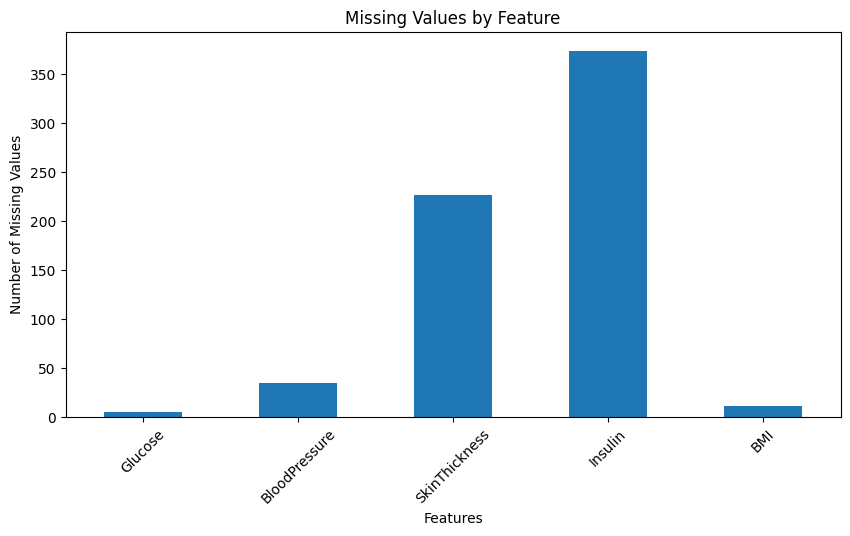

In [ ]:
# Missing Values Bar Plot

missing_counts = df_clean.isnull().sum()

missing_counts = missing_counts[missing_counts > 0]

plt.figure(figsize=(10, 5))

missing_counts.plot(kind="bar")

plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)
plt.show()

In [ ]:
# Block 15: Handle Missing Values using Median Imputation

for column in clinical_columns:
    median_value = df_clean[column].median()
    df_clean[column] = df_clean[column].fillna(median_value)

print("Missing values successfully imputed using median.")

print("Missing values after imputation:")

print(df_clean.isnull().sum())

Missing values successfully imputed using median.
Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# Block 17: Outlier Detection using IQR

numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns

outlier_summary = {}

for column in numeric_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    outlier_summary[column] = len(outliers)

outlier_summary

{'Pregnancies': 4,
 'Glucose': 0,
 'BloodPressure': 14,
 'SkinThickness': 87,
 'Insulin': 346,
 'BMI': 8,
 'DiabetesPedigreeFunction': 29,
 'Age': 9,
 'Outcome': 0}

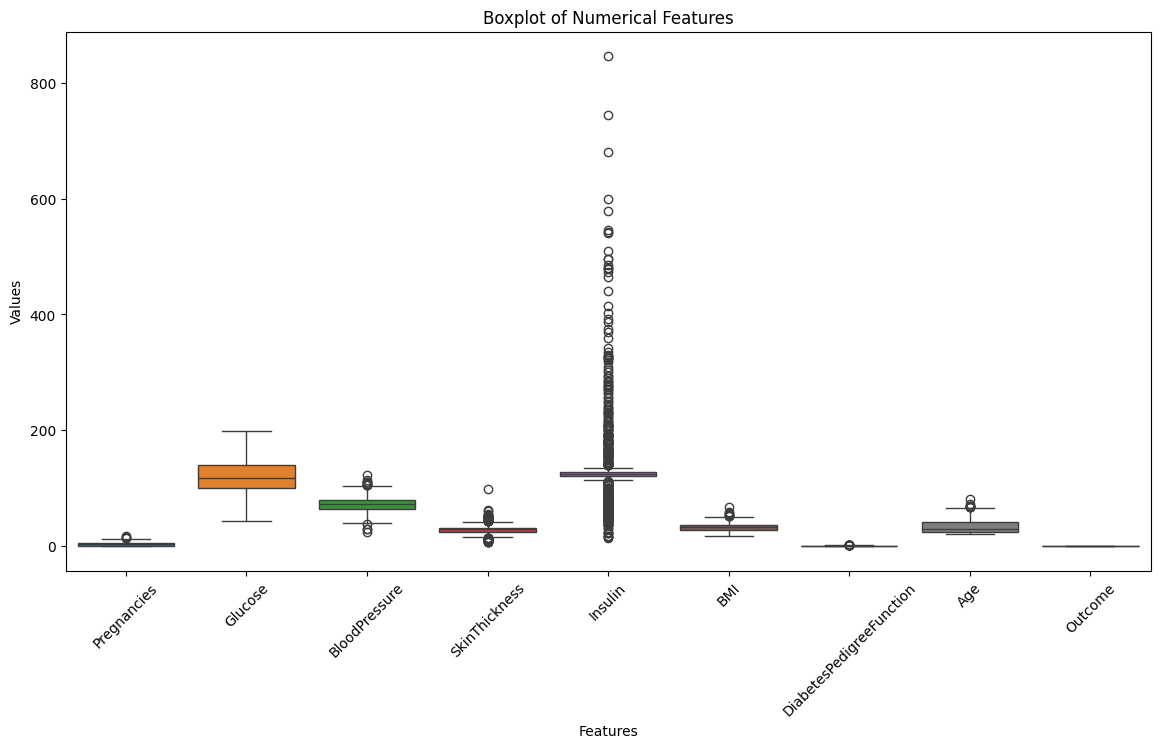

In [ ]:
# Block 18: Boxplots for Numerical Features

plt.figure(figsize=(14, 7))

sns.boxplot(data=df_clean)

plt.title("Boxplot of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.xticks(rotation=45)
plt.show()

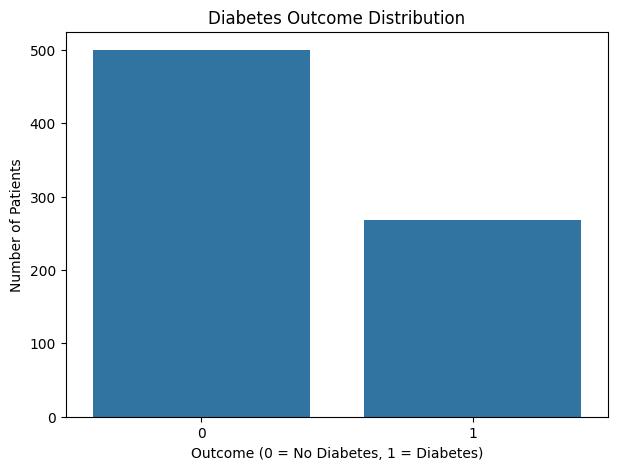

Outcome
0    500
1    268
Name: count, dtype: int64

Percentage Distribution:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [ ]:
#Visualize Outcome Distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df_clean, x="Outcome")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

print(df_clean["Outcome"].value_counts())

print("\nPercentage Distribution:")
print(df_clean["Outcome"].value_counts(normalize=True) * 100)

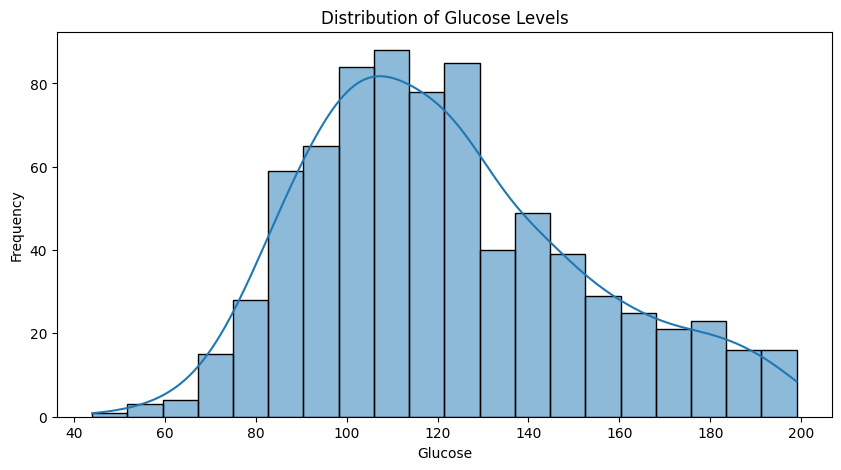

In [ ]:
# Distribution of Glucose

plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["Glucose"],
    bins=20,
    kde=True
)

plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.show()

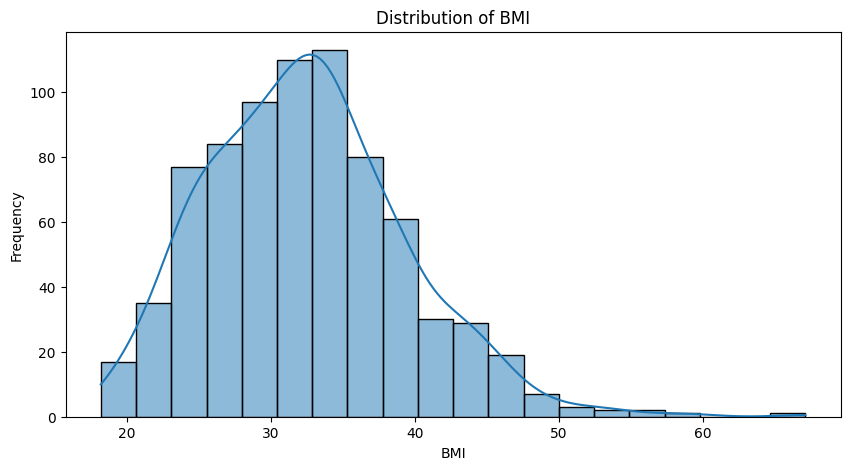

In [ ]:
# Distribution of BMI

plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["BMI"],
    bins=20,
    kde=True
)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

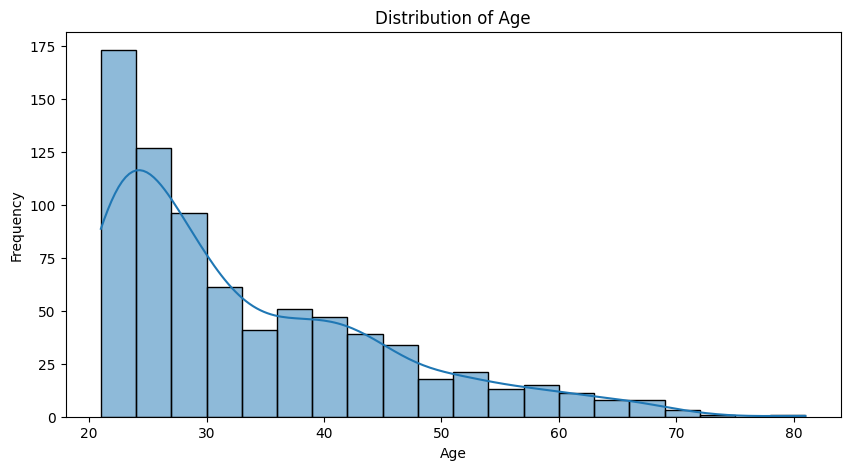

In [ ]:
# Block 23: Distribution of Age

plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["Age"],
    bins=20,
    kde=True
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

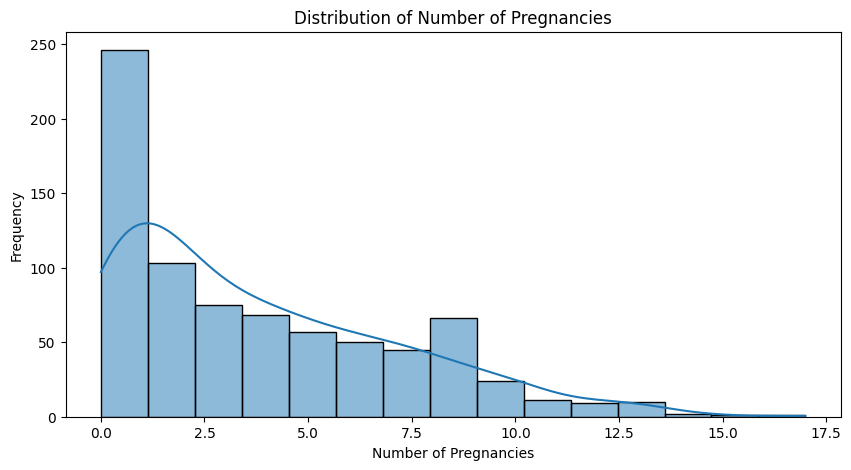

In [ ]:
# Block 24: Distribution of Pregnancies

plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["Pregnancies"],
    bins=15,
    kde= True
)

plt.title("Distribution of Number of Pregnancies")
plt.xlabel("Number of Pregnancies")
plt.ylabel("Frequency")

plt.show()

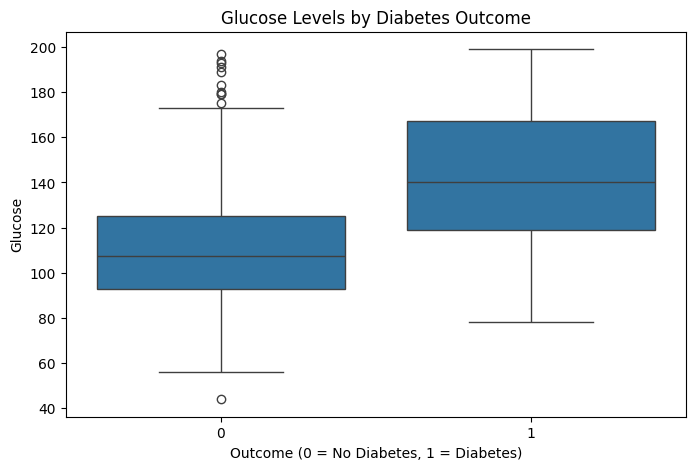

In [ ]:
#Glucose Levels by Diabetes Outcome

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Outcome",
    y="Glucose"
)

plt.title("Glucose Levels by Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Glucose")

plt.show()

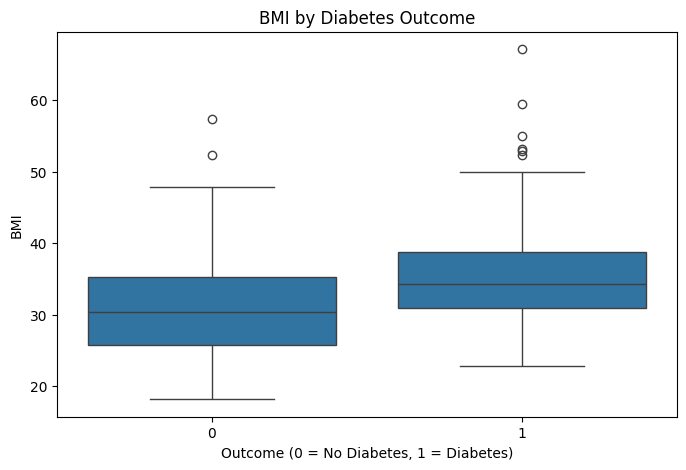

In [ ]:
# BMI by Diabetes Outcome

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Outcome",
    y="BMI"
)

plt.title("BMI by Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("BMI")

plt.show()

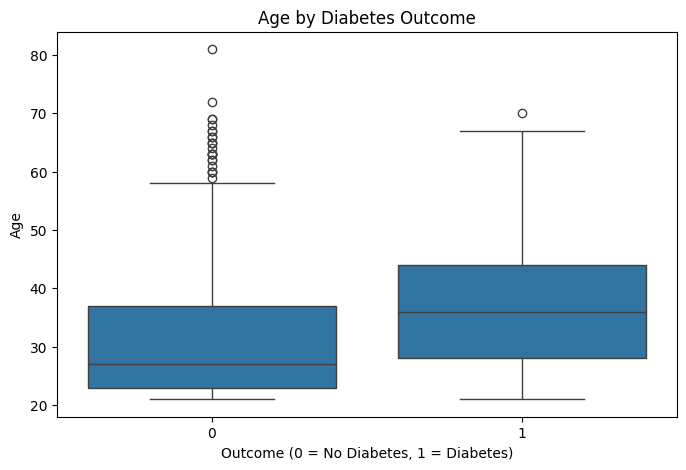

In [ ]:
# Age by Diabetes Outcome

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Outcome",
    y="Age"
)

plt.title("Age by Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Age")

plt.show()

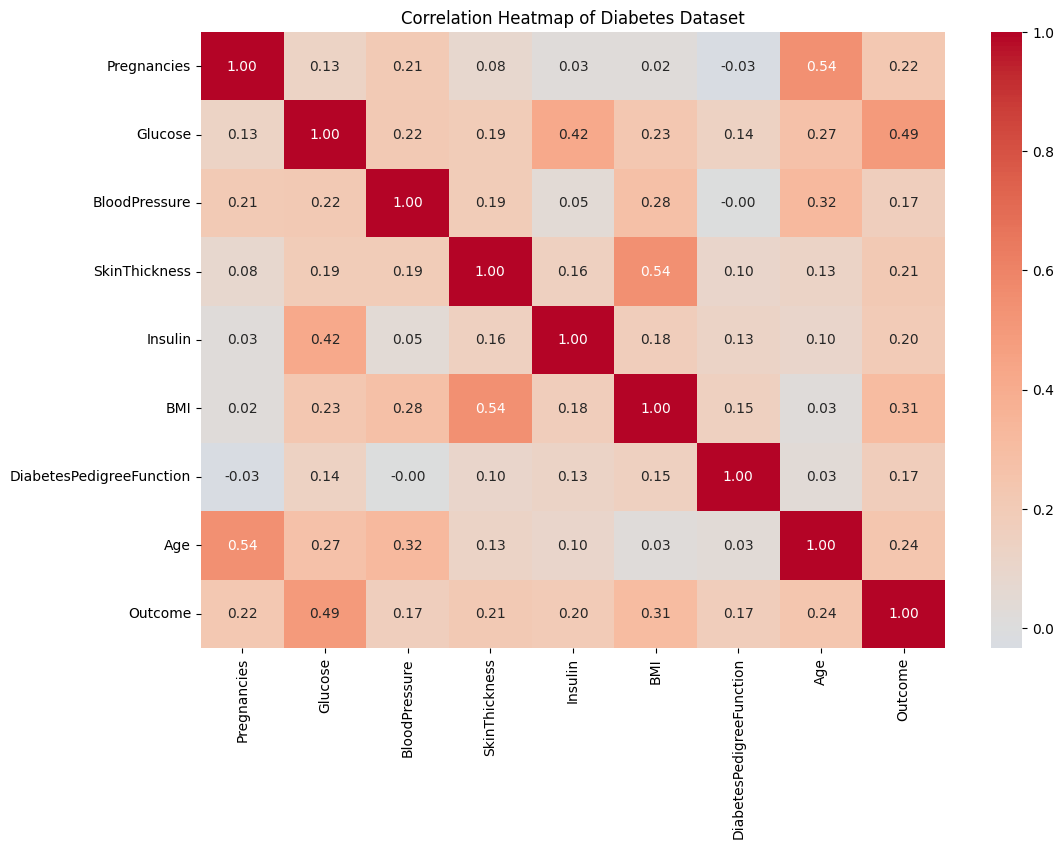

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

correlation_matrix = df_clean.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Diabetes Dataset")

plt.show()

In [ ]:
# Block 29: Correlation of Features with Outcome

outcome_correlation = (
    df_clean.corr()["Outcome"]
    .sort_values(ascending=False)
)

print(outcome_correlation)

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


In [ ]:
# Block 30: Separate Groups Based on Diabetes Outcome

non_diabetic = df_clean[df_clean["Outcome"] == 0]
diabetic = df_clean[df_clean["Outcome"] == 1]

print("Non-diabetic patients:", len(non_diabetic))
print("Diabetic patients:", len(diabetic))

Non-diabetic patients: 500
Diabetic patients: 268


In [ ]:
# Block 31: Independent T-Test for Glucose

t_stat, p_value = stats.ttest_ind(
    non_diabetic["Glucose"],
    diabetic["Glucose"],
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis (H0)")
    print("Conclusion: Glucose levels differ significantly between the two groups.")
else:
    print("Result: Fail to Reject the Null Hypothesis (H0)")
    print("Conclusion: No statistically significant difference was found.")

T-statistic: -14.852653441079662
P-value: 3.5421485614431447e-41
Result: Reject the Null Hypothesis (H0)
Conclusion: Glucose levels differ significantly between the two groups.


In [ ]:
# Block 32: Independent T-Test for BMI

t_stat_bmi, p_value_bmi = stats.ttest_ind(
    non_diabetic["BMI"],
    diabetic["BMI"],
    equal_var=False
)

print("T-statistic:", t_stat_bmi)
print("P-value:", p_value_bmi)

if p_value_bmi < 0.05:
    print("Result: Reject H0")
    print("Conclusion: BMI differs significantly between the two groups.")
else:
    print("Result: Fail to Reject H0")
    print("Conclusion: No statistically significant difference was found.")

T-statistic: -9.051746949833985
P-value: 2.552895685742694e-18
Result: Reject H0
Conclusion: BMI differs significantly between the two groups.


In [ ]:
# Block 33: Create BMI Categories

df_clean["BMI_Category"] = pd.cut(
    df_clean["BMI"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

df_clean[["BMI", "BMI_Category", "Outcome"]].head()

,BMI,BMI_Category,Outcome
0,33.6,Obese,1
1,26.6,Overweight,0
2,23.3,Normal,1
3,28.1,Overweight,0
4,43.1,Obese,1


In [ ]:
# Block 34: Chi-Square Test

contingency_table = pd.crosstab(
    df_clean["BMI_Category"],
    df_clean["Outcome"]
)

print("Contingency Table:")
print(contingency_table)

chi2_stat, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

print("\nChi-square statistic:", chi2_stat)
print("P-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Contingency Table:
Outcome         0    1
BMI_Category          
Underweight     4    0
Normal        101    7
Overweight    136   44
Obese         259  217

Chi-square statistic: 73.13331881767633
P-value: 9.101656268510895e-16
Degrees of freedom: 3


In [ ]:
# Block 35: Chi-Square Test Interpretation

alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis (H0)")
    print("Conclusion: BMI category and diabetes outcome are significantly associated.")
else:
    print("Result: Fail to Reject the Null Hypothesis (H0)")
    print("Conclusion: No significant association was found.")

Result: Reject the Null Hypothesis (H0)
Conclusion: BMI category and diabetes outcome are significantly associated.


In [ ]:
# Block 36: Create Age Groups

df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=[0, 30, 40, 50, np.inf],
    labels=["<=30", "31-40", "41-50", ">50"]
)

df_clean[["Age", "Age_Group"]].head()

,Age,Age_Group
0,50,41-50
1,31,31-40
2,32,31-40
3,21,<=30
4,33,31-40


In [ ]:
# Block 37: One-Way ANOVA

age_groups = [
    group["Glucose"].dropna()
    for _, group in df_clean.groupby("Age_Group", observed=True)
]

f_stat, p_value_anova = f_oneway(*age_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value_anova)

F-statistic: 19.733198998160084
P-value: 2.5012447956304365e-12


In [ ]:
# Block 38: ANOVA Interpretation

alpha = 0.05

if p_value_anova < alpha:
    print("Result: Reject the Null Hypothesis (H0)")
    print("Conclusion: Mean glucose levels differ significantly across age groups.")
else:
    print("Result: Fail to Reject the Null Hypothesis (H0)")
    print("Conclusion: No significant difference in mean glucose levels was found across age groups.")

Result: Reject the Null Hypothesis (H0)
Conclusion: Mean glucose levels differ significantly across age groups.


#Part B_Textual Medical Data (MTSamples)

In [ ]:
import re
import string

from collections import Counter

In [ ]:
# Block 2: Dataset using Direct URL

url = "https://raw.githubusercontent.com/aneuraz/mtsamplesFR/master/data/mtsamples.csv"

df_text = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df_text.shape)


df_text.head()

Dataset loaded successfully!
Shape: (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [ ]:
df_text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


In [ ]:
print("Columns in the dataset:")

for column in df_text.columns:
    print(column)

Columns in the dataset:
Unnamed: 0
description
medical_specialty
sample_name
transcription
keywords


In [ ]:
# Check Duplicates & Missing Values

duplicate_text = df_text.duplicated().sum()

print("Number of duplicate records:", duplicate_text)

missing_text = df_text.isnull().sum()

print("Missing values in each column:")
print(missing_text)

Number of duplicate records: 0
Missing values in each column:
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


In [ ]:
sample_text = df_text["transcription"].dropna().iloc[0]

print(sample_text)

SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has used Allegra also.  She used that last summer and she began using it again two weeks ago.  It does not appear to be working very well.  She has used over-the-counter sprays but no prescription nasal sprays.  She does have asthma but doest not require daily medication for this and does not think it is flaring up.,MEDICATIONS: , Her only medication currently is Ortho Tri-Cyclen and the Allegra.,ALLERGIES: , She has no known medicine allergies.,OBJECTIVE:,Vitals:  Weight was 130 pounds and blood pressure 124/78.,HEENT:  Her throat was mildly erythematous without exudate.  Nasal mucosa was erythematous and swollen.  Only clear drainage was seen.  TMs were clear.,Neck:  Supple without adenopathy.,L

In [ ]:
# Basic PHI(Protected Health Information) Removal Function

def remove_phi(text):
    if pd.isna(text):
        return text

    text = str(text)

    # Remove email addresses
    text = re.sub(
        r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b',
        '[EMAIL]',
        text
    )

    # Remove phone numbers
    text = re.sub(
        r'\b(?:\+?\d{1,3}[-.\s]?)?(?:\(?\d{3}\)?[-.\s]?)\d{3}[-.\s]?\d{4}\b',
        '[PHONE]',
        text
    )

    # Remove common date formats
    text = re.sub(
        r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b',
        '[DATE]',
        text
    )

    # Remove long numeric identifiers
    text = re.sub(
        r'\b\d{6,}\b',
        '[ID]',
        text
    )

    return text

In [ ]:
# Apply PHI De-identification

df_text["transcription_deidentified"] = (
    df_text["transcription"]
    .apply(remove_phi)
)

print("PHI removal process completed.")

PHI removal process completed.


In [ ]:
#Compare Original and De-identified Text

comparison = df_text[
    ["transcription", "transcription_deidentified"]
].dropna().head(1)

comparison

,transcription,transcription_deidentified
0,"SUBJECTIVE:, This 23-year-old white female pr...","SUBJECTIVE:, This 23-year-old white female pr..."


In [ ]:
#Text Cleaning Function

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
#Apply Text Cleaning

df_text["cleaned_text"] = (
    df_text["transcription_deidentified"]
    .apply(clean_text)
)

df_text[[
    "transcription_deidentified",
    "cleaned_text"
]].head()

,transcription_deidentified,cleaned_text
0,"SUBJECTIVE:, This 23-year-old white female pr...",subjective this 23yearold white female present...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",past medical history he has difficulty climbin...
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",history of present illness i have seen abc tod...
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",2d mmode 1 left atrial enlargement with left a...
4,1. The left ventricular cavity size and wall ...,1 the left ventricular cavity size and wall th...


In [ ]:
#Calculate Text Length

df_text["word_count"] = (
    df_text["cleaned_text"]
    .apply(lambda x: len(x.split()))
)

df_text["character_count"] = (
    df_text["cleaned_text"]
    .apply(len)
)

df_text[[
    "word_count",
    "character_count"
]].describe()

,word_count,character_count
count,4999.000000,4999.000000
mean,459.030606,2889.837167
std,316.780900,1927.527083
min,0.000000,0.000000
25%,236.000000,1510.500000
50%,392.000000,2524.000000
75%,609.000000,3815.000000
max,3025.000000,17863.000000


In [ ]:
# Medical Specialty Distribution

print("Number of unique medical specialties:",
      df_text["medical_specialty"].nunique())

print("\nMedical Specialties:")
print(df_text["medical_specialty"].value_counts())

Number of unique medical specialties: 40

Medical Specialties:
medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           158
Discharge Summary                 108
ENT - Otolaryngology               98
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    62
Psychiatry / Psychology            53
Office Notes                       51
Podiatry                           47
Dermatology                        29
Dentist

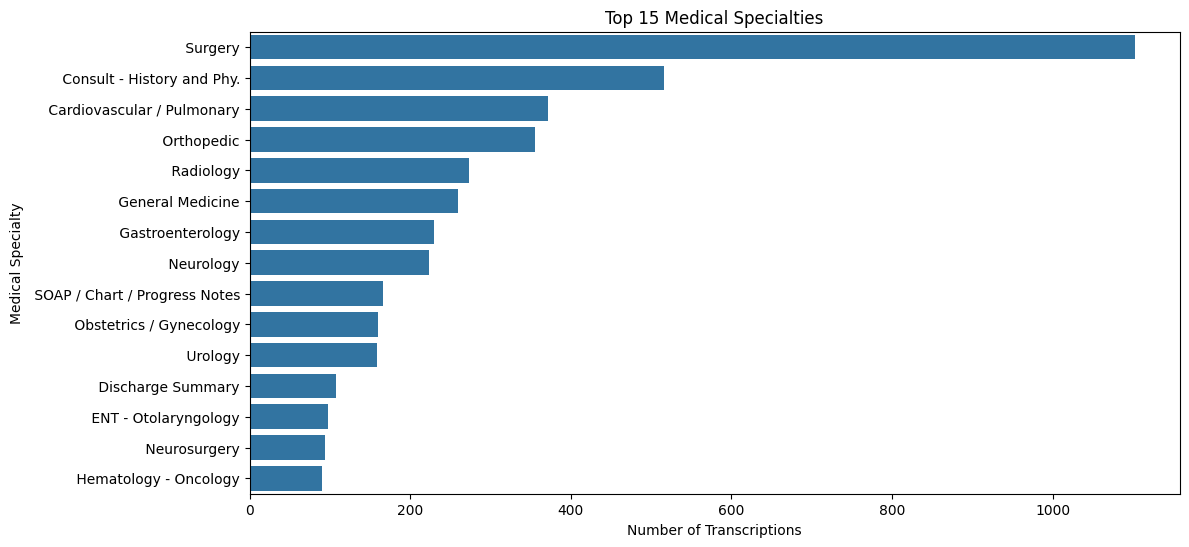

In [ ]:
# Block 16: Medical Specialty Distribution Plot

specialty_counts = df_text["medical_specialty"].value_counts().head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=specialty_counts.values,
    y=specialty_counts.index
)

plt.title("Top 15 Medical Specialties")
plt.xlabel("Number of Transcriptions")
plt.ylabel("Medical Specialty")

plt.show()

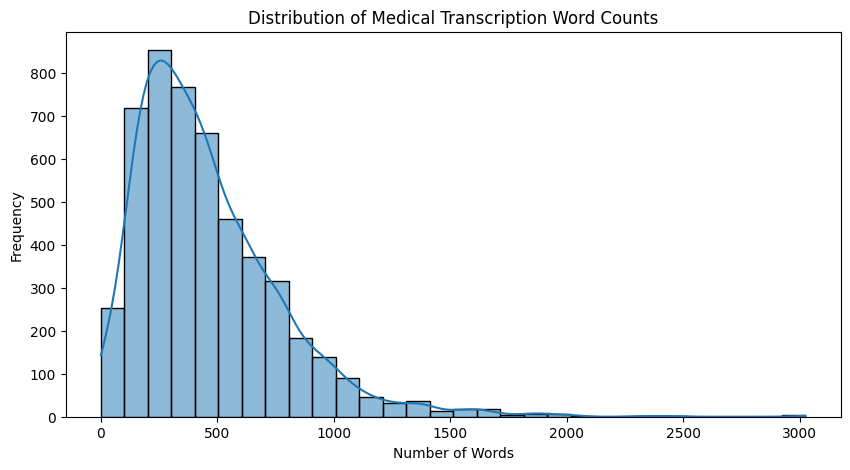

In [ ]:
# Block 17: Distribution of Word Counts

plt.figure(figsize=(10, 5))

sns.histplot(
    df_text["word_count"],
    bins=30,
    kde=True
)

plt.title("Distribution of Medical Transcription Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

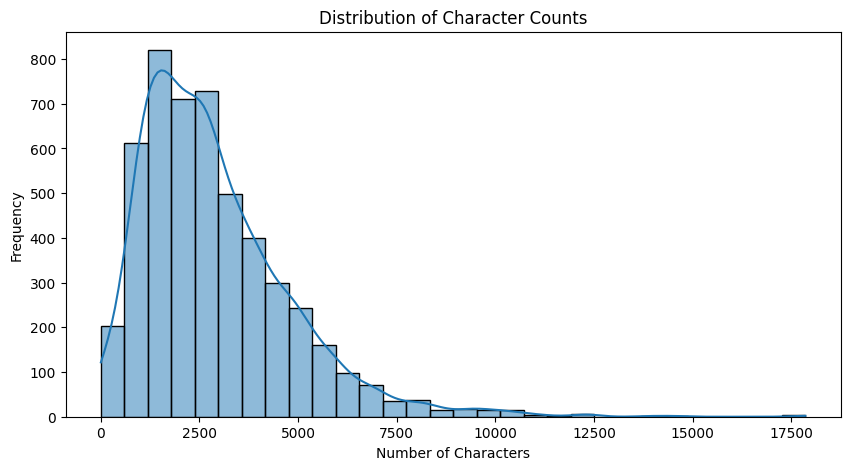

In [ ]:
# Block 18: Distribution of Character Counts

plt.figure(figsize=(10, 5))

sns.histplot(
    df_text["character_count"],
    bins=30,
    kde=True
)

plt.title("Distribution of Character Counts")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Block 19: Most Common Words

all_words = " ".join(
    df_text["cleaned_text"].dropna()
).split()

word_frequency = Counter(all_words)

common_words = word_frequency.most_common(20)

for word, count in common_words:
    print(f"{word}: {count}")

the: 147630
and: 82610
was: 71765
of: 59003
to: 50146
a: 42143
with: 35712
in: 32619
is: 26377
patient: 21902
no: 17761
she: 17338
for: 17028
were: 15535
he: 15295
on: 14523
this: 13787
at: 13252
then: 12373
right: 11101


In [ ]:
# Block 20: Download NLTK Stopwords

import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print("Number of stopwords:", len(stop_words))

Number of stopwords: 198


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Block 21: Stopword Removal

def remove_stopwords(text):
    words = text.split()

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)


df_text["processed_text"] = (
    df_text["cleaned_text"]
    .apply(remove_stopwords)
)

df_text[[
    "cleaned_text",
    "processed_text"
]].head()

,cleaned_text,processed_text
0,subjective this 23yearold white female present...,subjective 23yearold white female presents com...
1,past medical history he has difficulty climbin...,past medical history difficulty climbing stair...
2,history of present illness i have seen abc tod...,history present illness seen abc today pleasan...
3,2d mmode 1 left atrial enlargement with left a...,2d mmode 1 left atrial enlargement left atrial...
4,1 the left ventricular cavity size and wall th...,1 left ventricular cavity size wall thickness ...


In [ ]:
# Block 22: Most Common Words After Stopword Removal

all_words_processed = " ".join(
    df_text["processed_text"].dropna()
).split()

word_frequency_processed = Counter(all_words_processed)

common_words_processed = (
    word_frequency_processed.most_common(20)
)

for word, count in common_words_processed:
    print(f"{word}: {count}")

patient: 21902
right: 11101
left: 10749
history: 8083
placed: 6960
normal: 6717
well: 5856
pain: 5352
procedure: 5000
also: 4311
using: 4060
mg: 3909
time: 3882
noted: 3869
blood: 3813
without: 3730
incision: 3557
used: 3511
performed: 3501
removed: 3480


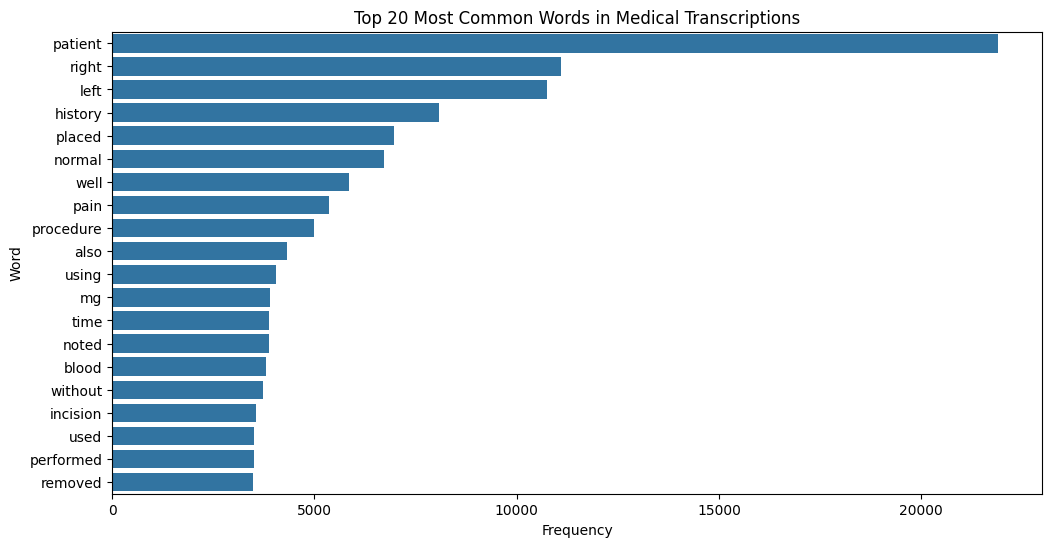

In [ ]:
# Block 23: Most Common Words Visualization

common_df = pd.DataFrame(
    common_words_processed,
    columns=["Word", "Frequency"]
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=common_df,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Most Common Words in Medical Transcriptions")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [ ]:
# Block 24: Tokenization

df_text["tokens"] = (
    df_text["processed_text"]
    .apply(lambda x: x.split())
)

df_text[["processed_text", "tokens"]].head()

,processed_text,tokens
0,subjective 23yearold white female presents com...,"[subjective, 23yearold, white, female, present..."
1,past medical history difficulty climbing stair...,"[past, medical, history, difficulty, climbing,..."
2,history present illness seen abc today pleasan...,"[history, present, illness, seen, abc, today, ..."
3,2d mmode 1 left atrial enlargement left atrial...,"[2d, mmode, 1, left, atrial, enlargement, left..."
4,1 left ventricular cavity size wall thickness ...,"[1, left, ventricular, cavity, size, wall, thi..."


In [ ]:
# Block 25: Calculate Token Count

df_text["token_count"] = (
    df_text["tokens"].apply(len)
)

print(df_text["token_count"].describe())

count    4999.000000
mean      272.912583
std       180.546913
min         0.000000
25%       143.000000
50%       240.000000
75%       358.000000
max      1712.000000
Name: token_count, dtype: float64


In [ ]:
# Block 26: TF-IDF Feature Extraction

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000,
    min_df=2,
    max_df=0.95
)

X_text = tfidf.fit_transform(
    df_text["processed_text"]
)

print("TF-IDF matrix shape:", X_text.shape)

TF-IDF matrix shape: (4999, 1000)


In [ ]:
# Block 27: Display Extracted TF-IDF Features

feature_names = tfidf.get_feature_names_out()

print("Number of extracted features:", len(feature_names))

print("\nFirst 30 features:")
print(feature_names[:30])

# Block 28: Convert TF-IDF Matrix to DataFrame

tfidf_df = pd.DataFrame(
    X_text.toarray(),
    columns=feature_names
)

tfidf_df.head()

Number of extracted features: 1000

First 30 features:
['025' '05' '10' '100' '11' '12' '13' '14' '15' '16' '18' '20' '22' '24'
 '25' '30' '35' '40' '45' '50' '55' '60' '70' '75' '80' '90' 'abc' 'abcd'
 'abdomen' 'abdominal']


,025,05,10,100,11,12,13,14,15,16,...,work,workup,worse,would,wound,wrist,xray,xyz,year,years
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.15741,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,0.0,0.0,0.000000,0.0,0.0,0.0,0.091520,0.0,0.000000,0.0,...,0.0,0.000000,0.00000,0.120316,0.0,0.0,0.0,0.000000,0.079274,0.065603
2,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.037331,0.0,...,0.0,0.054405,0.00000,0.070979,0.0,0.0,0.0,0.158141,0.046766,0.193508
3,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
4,0.0,0.0,0.041701,0.0,0.0,0.0,0.071782,0.0,0.000000,0.0,...,0.0,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [ ]:
# Block 29: Prepare Final Text Dataset

final_text_df = tfidf_df.copy()

final_text_df["medical_specialty"] = (
    df_text["medical_specialty"].values
)

print("Final text dataset shape:",
      final_text_df.shape)

final_text_df.head()

Final text dataset shape: (4999, 1001)


,025,05,10,100,11,12,13,14,15,16,...,workup,worse,would,wound,wrist,xray,xyz,year,years,medical_specialty
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.000000,0.15741,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,Allergy / Immunology
1,0.0,0.0,0.000000,0.0,0.0,0.0,0.091520,0.0,0.000000,0.0,...,0.000000,0.00000,0.120316,0.0,0.0,0.0,0.000000,0.079274,0.065603,Bariatrics
2,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.037331,0.0,...,0.054405,0.00000,0.070979,0.0,0.0,0.0,0.158141,0.046766,0.193508,Bariatrics
3,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,Cardiovascular / Pulmonary
4,0.0,0.0,0.041701,0.0,0.0,0.0,0.071782,0.0,0.000000,0.0,...,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,Cardiovascular / Pulmonary


#Part C_Image Data (Chest X-Ray/Pneumonia)

In [ ]:
# Block 1: Import Required Libraries

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Block 2: Dataset Acquisition using URL

!git clone https://github.com/probml/chest_xray_kaggle.git /content/chest_xray

print("Dataset acquired successfully!")

Cloning into '/content/chest_xray'...
remote: Enumerating objects: 5847, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 5847 (delta 0), reused 4 (delta 0), pack-reused 5843 (from 1)
Receiving objects: 100% (5847/5847), 1.13 GiB | 29.36 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Updating files: 100% (5865/5865), done.
Dataset acquired successfully!


In [ ]:
# Block 3: Inspect Dataset

import os

print(os.listdir("/content/chest_xray"))

['README.md', '.git', 'train', 'test', 'LICENSE', 'val']


In [ ]:
# Block 4: Check Dataset Classes

train_path = "/content/chest_xray/train"

print("Classes:")
print(os.listdir(train_path))

Classes:
['NORMAL', '.DS_Store', 'PNEUMONIA']


In [ ]:
# Block 5: Count Images

for class_name in ["NORMAL", "PNEUMONIA"]:

    class_path = os.path.join(train_path, class_name)

    image_count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    print(f"{class_name}: {image_count}")

NORMAL: 1341
PNEUMONIA: 3875


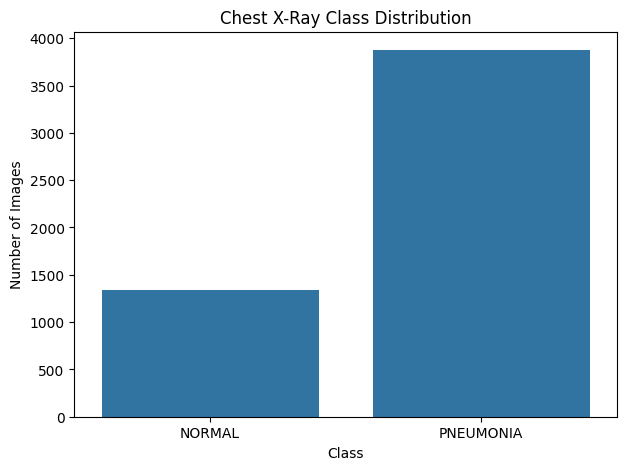

In [ ]:
# Block 7: Class Distribution Visualization

plt.figure(figsize=(7, 5))

sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.title("Chest X-Ray Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

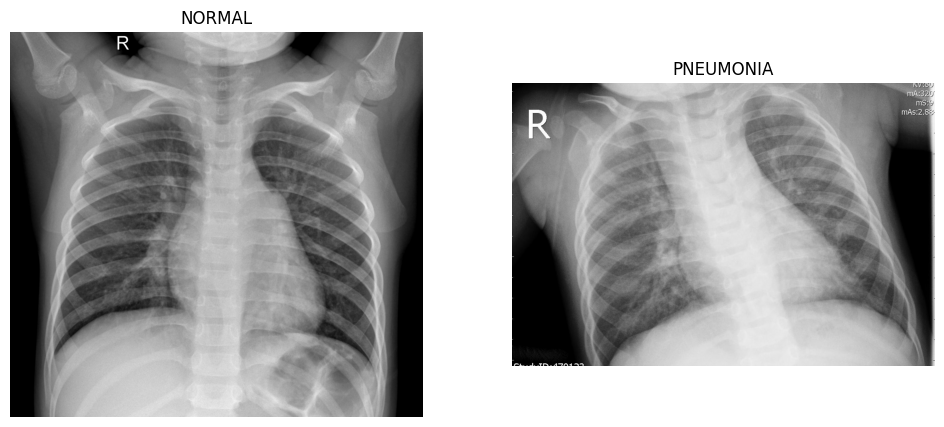

In [ ]:
# Block 9: Display Normal and Pneumonia X-Rays

from PIL import Image

normal_image = Image.open(
    os.path.join(normal_path, normal_images[0])
)

pneumonia_image = Image.open(
    os.path.join(pneumonia_path, pneumonia_images[0])
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(normal_image, cmap="gray")
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pneumonia_image, cmap="gray")
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

In [ ]:
# Block 10: Inspect Image Properties

print("Normal Image")
print("Format:", normal_image.format)
print("Size:", normal_image.size)
print("Mode:", normal_image.mode)

print("\nPneumonia Image")
print("Format:", pneumonia_image.format)
print("Size:", pneumonia_image.size)
print("Mode:", pneumonia_image.mode)

Normal Image
Format: JPEG
Size: (1924, 1797)
Mode: L

Pneumonia Image
Format: JPEG
Size: (1280, 856)
Mode: L


In [ ]:
# Block 11: Analyze Image Dimensions

image_dimensions = []

for class_name in classes:

    class_path = os.path.join(
        train_path,
        class_name
    )

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Analyze first 100 images from each class
    for file in image_files[:100]:

        image_path = os.path.join(
            class_path,
            file
        )

        with Image.open(image_path) as img:
            width, height = img.size

            image_dimensions.append({
                "Class": class_name,
                "Width": width,
                "Height": height
            })

dimension_df = pd.DataFrame(image_dimensions)

dimension_df.head()

,Class,Width,Height
0,NORMAL,1924,1797
1,NORMAL,1798,1356
2,NORMAL,1306,994
3,NORMAL,1840,1507
4,NORMAL,1450,1160


In [ ]:
# Block 12: Image Dimension Statistics

dimension_df.groupby("Class")[["Width", "Height"]].describe()

Width                                                              \
           count     mean         std    min     25%     50%     75%     max   
Class                                                                          
NORMAL     100.0  1656.77  267.712791  992.0  1457.5  1641.0  1800.5  2538.0   
PNEUMONIA  100.0  1230.25  283.684039  446.0  1008.0  1200.0  1417.5  2072.0   

          Height                                                                
           count     mean         std    min      25%     50%      75%     max  
Class                                                                           
NORMAL     100.0  1378.42  292.317600  816.0  1159.75  1347.0  1519.75  2543.0  
PNEUMONIA  100.0   840.11  248.898174  186.0   680.00   844.0   960.00  1768.0

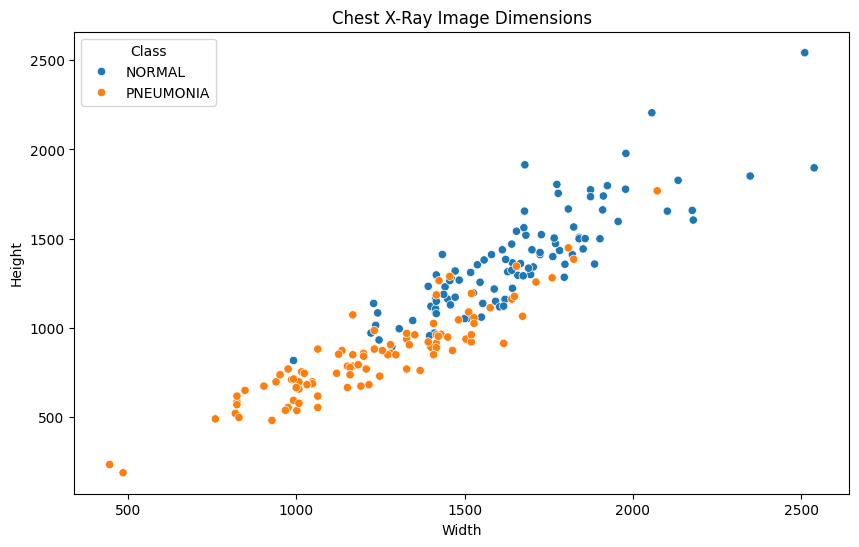

In [ ]:
# Block 13: Visualize Image Dimensions

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=dimension_df,
    x="Width",
    y="Height",
    hue="Class"
)

plt.title("Chest X-Ray Image Dimensions")
plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

In [ ]:
# Block 14: Define Target Image Size

IMG_SIZE = (224, 224)

print("Target image size:", IMG_SIZE)

Target image size: (224, 224)


In [ ]:
# Block 15: Resize Sample Image

resized_image = normal_image.resize(IMG_SIZE)

print("Original size:", normal_image.size)
print("Resized size:", resized_image.size)

Original size: (1924, 1797)
Resized size: (224, 224)


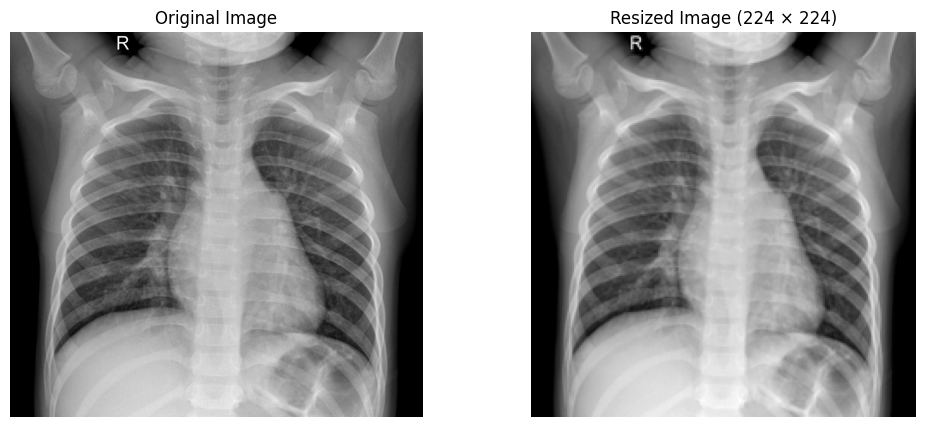

In [ ]:
# Block 16: Compare Original and Resized Image

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(normal_image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_image, cmap="gray")
plt.title("Resized Image (224 × 224)")
plt.axis("off")

plt.show()

In [ ]:
image_array = np.array(resized_image)

print("Array shape:", image_array.shape)
print("Data type:", image_array.dtype)
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

Array shape: (224, 224)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 238


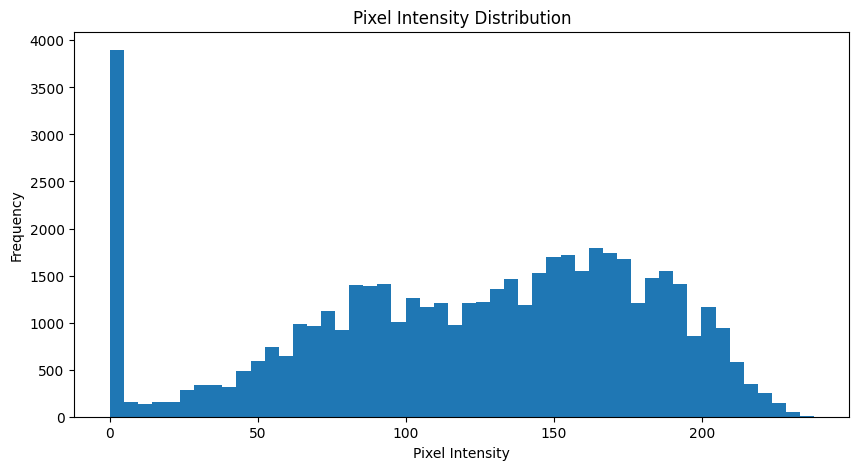

In [ ]:
# Block 18: Pixel Intensity Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    image_array.ravel(),
    bins=50
)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Block 19: Normalize Pixel Values

normalized_image = image_array / 255.0

print("Minimum after normalization:",
      normalized_image.min())

print("Maximum after normalization:",
      normalized_image.max())

Minimum after normalization: 0.0
Maximum after normalization: 1.0


In [ ]:
image_tensor = np.expand_dims(
    normalized_image,
    axis=-1
)

print("Tensor shape:", image_tensor.shape)

Tensor shape: (224, 224, 1)


In [ ]:
# Block 21: Image Preprocessing Function

def preprocess_image(image_path, img_size=(224, 224)):

    # Load image
    image = Image.open(image_path)

    # Convert to grayscale
    image = image.convert("L")

    # Resize
    image = image.resize(img_size)

    # Convert to NumPy array
    image_array = np.array(image, dtype=np.float32)

    # Normalize pixel values
    image_array = image_array / 255.0

    # Add channel dimension
    image_array = np.expand_dims(
        image_array,
        axis=-1
    )

    return image_array

In [ ]:
# Block 22: Test Image Preprocessing

# Select a sample NORMAL image
normal_path = os.path.join(train_path, "NORMAL")

normal_images = [
    file for file in os.listdir(normal_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]

sample_path = os.path.join(
    normal_path,
    normal_images[0]
)

# Preprocess the image
processed_image = preprocess_image(sample_path)

print("Processed image shape:", processed_image.shape)
print("Minimum pixel value:", processed_image.min())
print("Maximum pixel value:", processed_image.max())

Processed image shape: (224, 224, 1)
Minimum pixel value: 0.0
Maximum pixel value: 0.93333334


In [ ]:
# Block 23: Image Augmentation

import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),
    tf.keras.layers.RandomFlip("horizontal")
])

print("Image augmentation pipeline created!")

Image augmentation pipeline created!


In [ ]:
# Block 24: Apply Augmentation

# Add batch dimension
input_tensor = tf.expand_dims(
    processed_image,
    axis=0
)

# Apply augmentation
augmented_image = data_augmentation(
    input_tensor,
    training=True
)

# Remove batch dimension
augmented_image = augmented_image[0]

print("Original shape:", processed_image.shape)
print("Augmented shape:", augmented_image.shape)

Original shape: (224, 224, 1)
Augmented shape: (224, 224, 1)


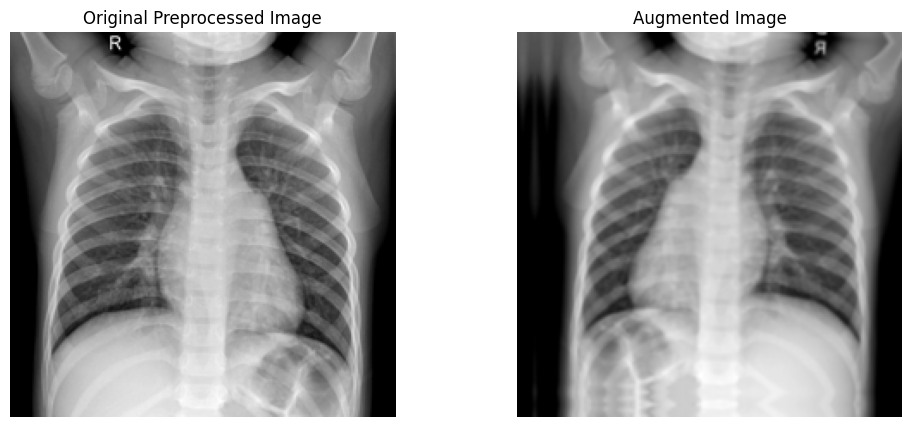

In [ ]:
# Block 25: Compare Original and Augmented Images

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    processed_image.squeeze(),
    cmap="gray"
)
plt.title("Original Preprocessed Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    augmented_image.numpy().squeeze(),
    cmap="gray"
)
plt.title("Augmented Image")
plt.axis("off")

plt.show()

In [ ]:
# Block 26: Check Augmented Image Pixel Range

print(
    "Minimum pixel value:",
    float(tf.reduce_min(augmented_image))
)

print(
    "Maximum pixel value:",
    float(tf.reduce_max(augmented_image))
)

Minimum pixel value: 0.0
Maximum pixel value: 0.9142956733703613


In [ ]:
# Block 27: Complete Image Preprocessing Function

def preprocess_image(image_path, img_size=(224, 224)):

    image = Image.open(image_path)

    # Convert to grayscale
    image = image.convert("L")

    # Resize image
    image = image.resize(img_size)

    # Convert to NumPy array
    image_array = np.array(
        image,
        dtype=np.float32
    )

    # Normalize pixel values
    image_array = image_array / 255.0

    # Add channel dimension
    image_array = np.expand_dims(
        image_array,
        axis=-1
    )

    return image_array

In [ ]:
# Block 28: Process Multiple X-Ray Images

X_images = []
y_labels = []

max_images_per_class = 100

label_map = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}

for class_name in classes:

    class_path = os.path.join(
        train_path,
        class_name
    )

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    for file in image_files[:max_images_per_class]:

        image_path = os.path.join(
            class_path,
            file
        )

        processed = preprocess_image(
            image_path
        )

        X_images.append(processed)
        y_labels.append(label_map[class_name])

X_images = np.array(X_images)
y_labels = np.array(y_labels)

print("Image data shape:", X_images.shape)
print("Label shape:", y_labels.shape)

Image data shape: (200, 224, 224, 1)
Label shape: (200,)


In [ ]:
# Block 29: Verify Image Labels

print("Label distribution:")

unique, counts = np.unique(
    y_labels,
    return_counts=True
)

for label, count in zip(unique, counts):

    class_name = (
        "NORMAL"
        if label == 0
        else "PNEUMONIA"
    )

    print(f"{class_name}: {count}")

Label distribution:
NORMAL: 100
PNEUMONIA: 100


In [ ]:
# Block 30: Final Model-Ready Data

print("Final Image Data Shape:", X_images.shape)
print("Final Labels Shape:", y_labels.shape)

print("Data Type:", X_images.dtype)
print(
    "Pixel Range:",
    X_images.min(),
    "to",
    X_images.max()
)

Final Image Data Shape: (200, 224, 224, 1)
Final Labels Shape: (200,)
Data Type: float32
Pixel Range: 0.0 to 1.0


#Part_D SIGNAL DATA / ECG

In [ ]:
# Part D: Signal Medical Data
# Block 1: Import Required Libraries

!pip install wfdb -q

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal

print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 1.5 MB/s eta 0:00:00
Libraries imported successfully!


In [ ]:
# Block 2: Acquire MIT-BIH ECG Record from PhysioNet

record_name = "100"

record = wfdb.rdrecord(
    record_name,
    pn_dir="mitdb"
)

print("ECG record acquired successfully!")
print("Record:", record_name)

ECG record acquired successfully!
Record: 100


In [ ]:
# Block 3: Inspect ECG Record

print("Sampling Frequency:", record.fs)
print("Number of Samples:", record.sig_len)
print("Number of Channels:", record.n_sig)
print("Signal Names:", record.sig_name)

Sampling Frequency: 360
Number of Samples: 650000
Number of Channels: 2
Signal Names: ['MLII', 'V5']


In [ ]:
# Block 4: Extract ECG Signal

ecg_signal = record.p_signal

print("ECG Signal Shape:", ecg_signal.shape)
print("Data Type:", ecg_signal.dtype)

ECG Signal Shape: (650000, 2)
Data Type: float64


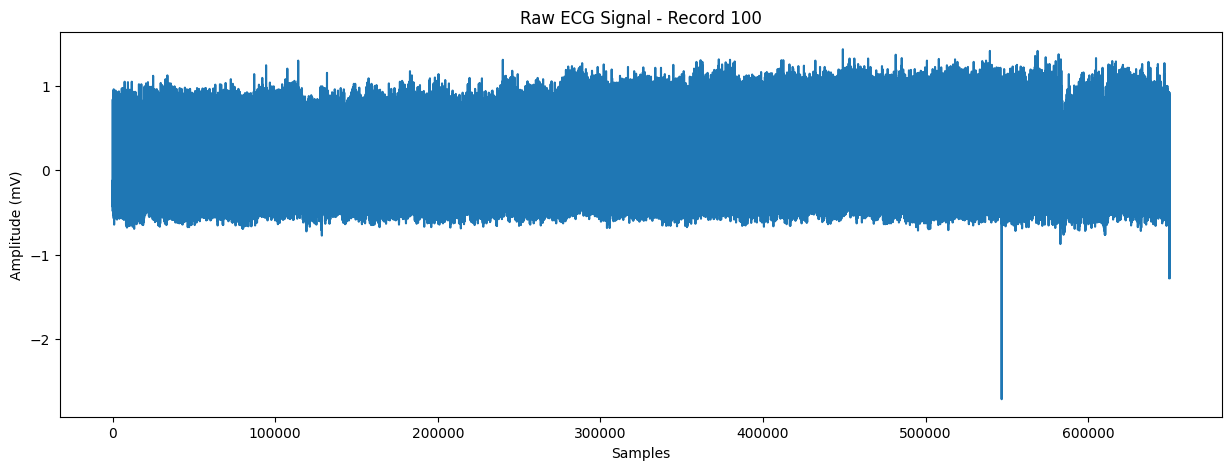

In [ ]:
# Block 5: Visualize Raw ECG Signal

plt.figure(figsize=(15, 5))

plt.plot(
    ecg_signal[:, 0]
)

plt.title("Raw ECG Signal - Record 100")
plt.xlabel("Samples")
plt.ylabel("Amplitude (mV)")

plt.show()

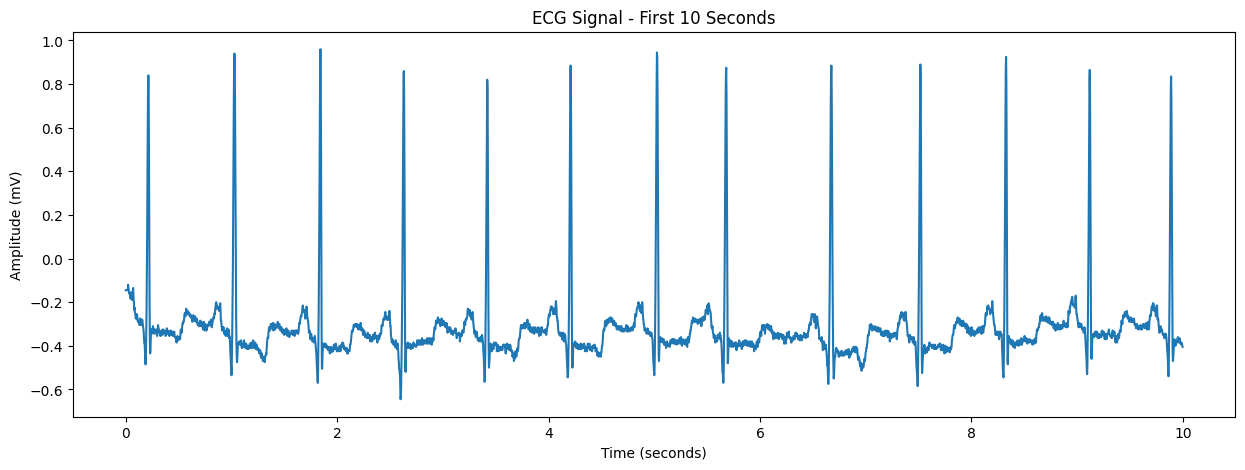

In [ ]:
# Block 6: ECG Signal - First 10 Seconds

fs = record.fs

seconds = 10

samples = int(
    fs * seconds
)

time = np.arange(samples) / fs

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    ecg_signal[:samples, 0]
)

plt.title("ECG Signal - First 10 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")

plt.show()

In [ ]:
# Block 7: Load ECG Annotations

annotation = wfdb.rdann(
    record_name,
    "atr",
    pn_dir="mitdb"
)

print("Annotations loaded successfully!")
print("Number of annotations:", len(annotation.sample))

Annotations loaded successfully!
Number of annotations: 2274


In [ ]:
# Block 8: Inspect Annotation Symbols

annotation_symbols = pd.Series(
    annotation.symbol
)

print(
    annotation_symbols.value_counts().head(20)
)

N    2239
A      33
+       1
V       1
Name: count, dtype: int64


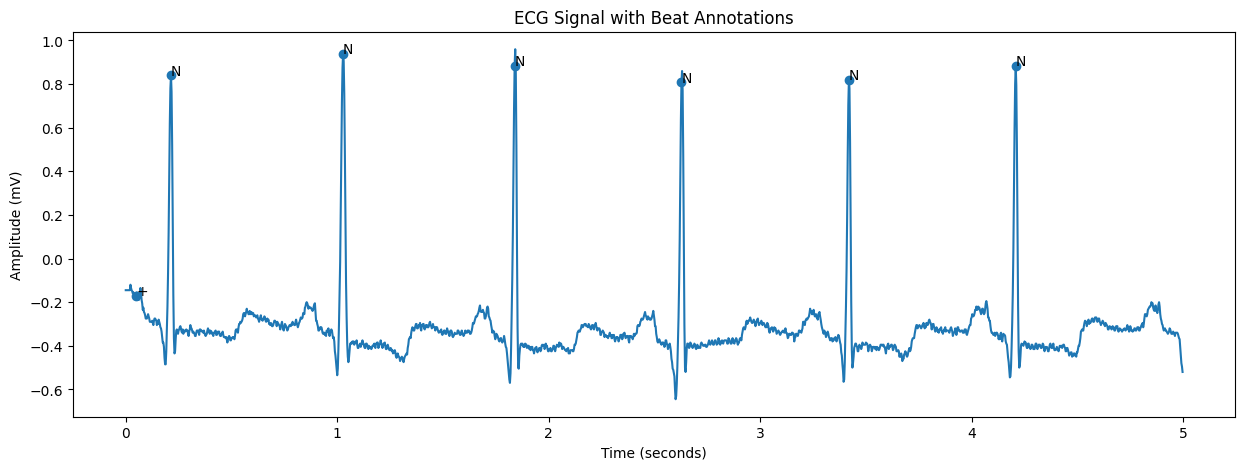

In [ ]:
# Block 9: ECG with Beat Annotations

samples = int(record.fs * 5)

plt.figure(figsize=(15, 5))

plt.plot(
    np.arange(samples) / record.fs,
    ecg_signal[:samples, 0]
)

annotation_samples = [
    s for s in annotation.sample
    if s < samples
]

annotation_symbols = [
    annotation.symbol[i]
    for i, s in enumerate(annotation.sample)
    if s < samples
]

plt.scatter(
    np.array(annotation_samples) / record.fs,
    ecg_signal[
        annotation_samples,
        0
    ]
)

for x, y, label in zip(
    np.array(annotation_samples) / record.fs,
    ecg_signal[annotation_samples, 0],
    annotation_symbols
):
    plt.text(x, y, label)

plt.title("ECG Signal with Beat Annotations")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")

plt.show()

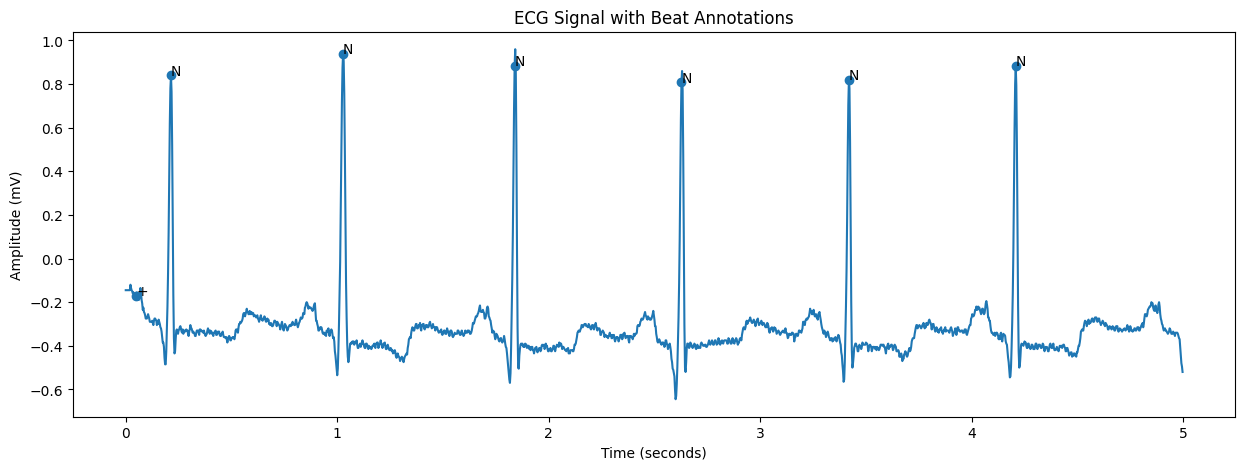

In [ ]:
# Block 9: ECG with Beat Annotations

samples = int(record.fs * 5)

plt.figure(figsize=(15, 5))

plt.plot(
    np.arange(samples) / record.fs,
    ecg_signal[:samples, 0]
)

annotation_samples = [
    s for s in annotation.sample
    if s < samples
]

annotation_symbols = [
    annotation.symbol[i]
    for i, s in enumerate(annotation.sample)
    if s < samples
]

plt.scatter(
    np.array(annotation_samples) / record.fs,
    ecg_signal[
        annotation_samples,
        0
    ]
)

for x, y, label in zip(
    np.array(annotation_samples) / record.fs,
    ecg_signal[annotation_samples, 0],
    annotation_symbols
):
    plt.text(x, y, label)

plt.title("ECG Signal with Beat Annotations")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")

plt.show()

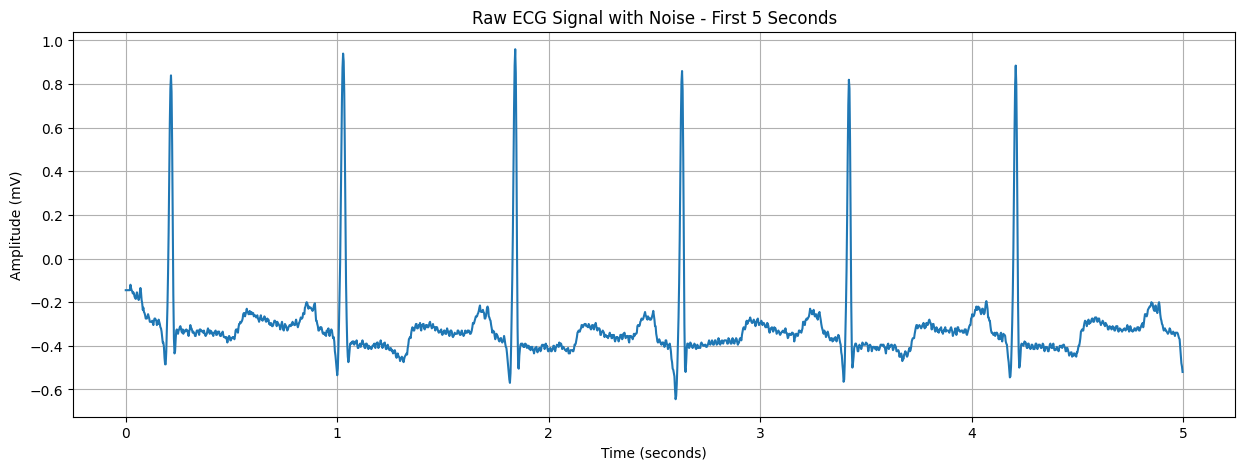

In [ ]:
# Block 11 — Visualize Raw ECG with Noise

# Select first ECG channel
ecg_channel = record.p_signal[:, 0]

# Show first 5 seconds
seconds = 5
samples = int(seconds * record.fs)

time = np.arange(samples) / record.fs

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    ecg_channel[:samples]
)

plt.title("Raw ECG Signal with Noise - First 5 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)

plt.show()

In [ ]:
# Block 12 — ECG Noise Filtering

low_cutoff = 0.5
high_cutoff = 40.0

nyquist_frequency = 0.5 * record.fs

low = low_cutoff / nyquist_frequency
high = high_cutoff / nyquist_frequency

b, a = signal.butter(
    4,
    [low, high],
    btype="bandpass"
)

print("Bandpass filter created successfully!")
print("Low cutoff:", low_cutoff, "Hz")
print("High cutoff:", high_cutoff, "Hz")

Bandpass filter created successfully!
Low cutoff: 0.5 Hz
High cutoff: 40.0 Hz


In [ ]:
# Block 13 — Apply Bandpass Filter

filtered_ecg = signal.filtfilt(
    b,
    a,
    ecg_channel
)

print("ECG filtering completed!")
print("Filtered ECG Shape:", filtered_ecg.shape)

ECG filtering completed!
Filtered ECG Shape: (650000,)


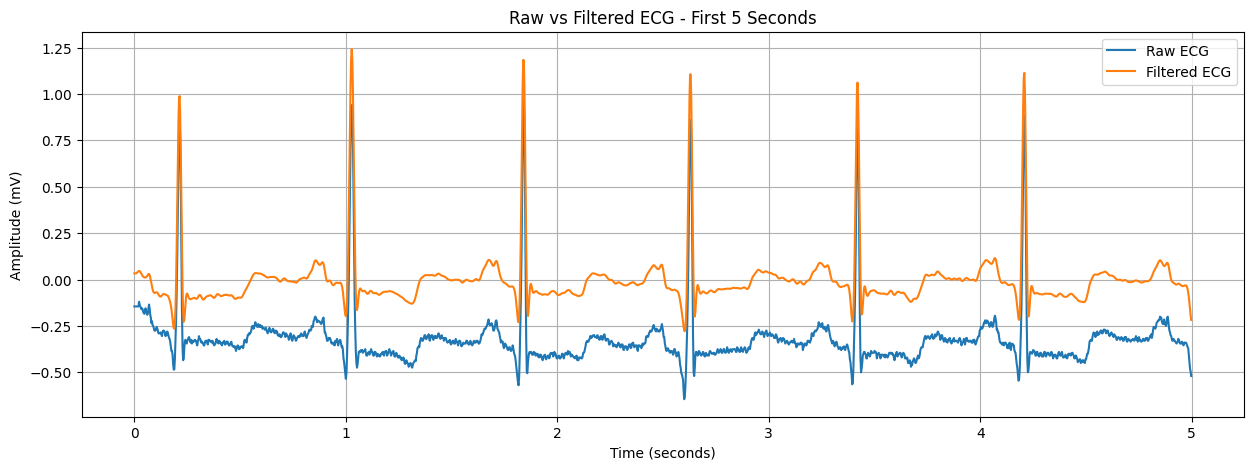

In [ ]:
# Block 14 — Compare Raw and Filtered ECG

seconds = 5
samples = int(seconds * record.fs)

time = np.arange(samples) / record.fs

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    ecg_channel[:samples],
    label="Raw ECG"
)

plt.plot(
    time,
    filtered_ecg[:samples],
    label="Filtered ECG"
)

plt.title("Raw vs Filtered ECG - First 5 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Block 15 — R-Peak Detection

distance = int(0.25 * record.fs)

peaks, properties = signal.find_peaks(
    filtered_ecg,
    distance=distance,
    prominence=0.5
)

print("R-peaks detected successfully!")
print("Number of R-peaks:", len(peaks))

R-peaks detected successfully!
Number of R-peaks: 2273


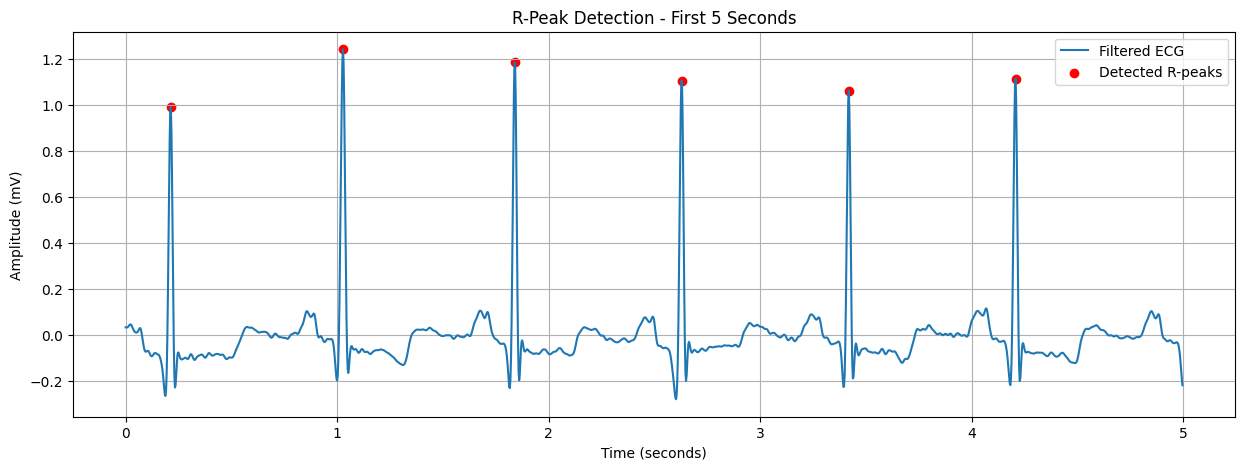

In [ ]:
# Block 16 — Visualize R-Peaks

seconds = 5
samples = int(seconds * record.fs)

time = np.arange(samples) / record.fs

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    filtered_ecg[:samples],
    label="Filtered ECG"
)

peak_mask = peaks < samples

plt.scatter(
    time[peaks[peak_mask]],
    filtered_ecg[peaks[peak_mask]],
    color="red",
    marker="o",
    label="Detected R-peaks"
)

plt.title("R-Peak Detection - First 5 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Block 17 — RR Interval Calculation

rr_intervals = np.diff(peaks) / record.fs

print("RR Interval Calculation Completed!")
print("Number of RR intervals:", len(rr_intervals))

print("\nFirst 10 RR intervals (seconds):")
print(rr_intervals[:10])

RR Interval Calculation Completed!
Number of RR intervals: 2272

First 10 RR intervals (seconds):
[0.81388889 0.81111111 0.79166667 0.78888889 0.78888889 0.81666667
 0.65277778 0.99722222 0.84166667 0.80833333]


In [ ]:
# Block 18 — Calculate Heart Rate

heart_rates = 60 / rr_intervals

print("Heart Rate Calculation Completed!")

print("\nFirst 10 Heart Rate Values (BPM):")
print(heart_rates[:10])

print("\nAverage Heart Rate:", np.mean(heart_rates), "BPM")

Heart Rate Calculation Completed!

First 10 Heart Rate Values (BPM):
[73.72013652 73.97260274 75.78947368 76.05633803 76.05633803 73.46938776
 91.91489362 60.16713092 71.28712871 74.22680412]

Average Heart Rate: 75.80764604749777 BPM


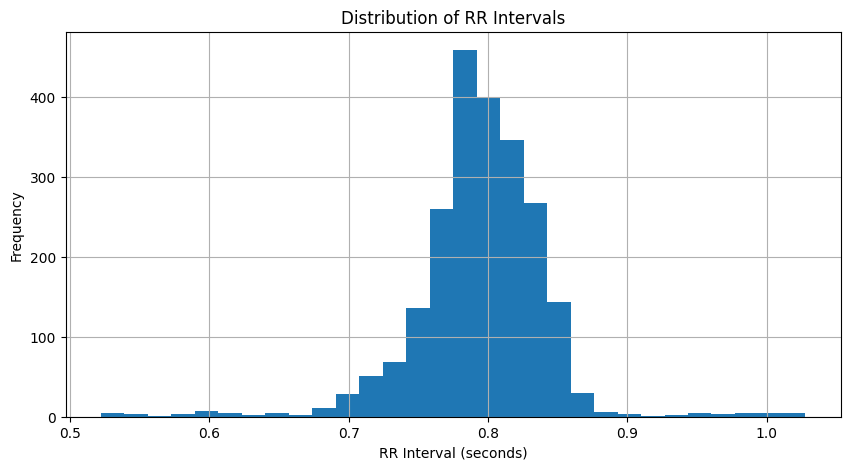

In [ ]:
# Block 19 — RR Interval Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    rr_intervals,
    bins=30
)

plt.title("Distribution of RR Intervals")
plt.xlabel("RR Interval (seconds)")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

In [ ]:
# Block 20 — Create ECG Beat Windows

window_before = int(0.5 * record.fs)
window_after = int(0.5 * record.fs)

ecg_windows = []

for peak in peaks:
    start = peak - window_before
    end = peak + window_after

    if start >= 0 and end < len(filtered_ecg):
        ecg_windows.append(filtered_ecg[start:end])

ecg_windows = np.array(ecg_windows)

print("ECG Windows Created Successfully!")
print("ECG Windows Shape:", ecg_windows.shape)

ECG Windows Created Successfully!
ECG Windows Shape: (2271, 360)


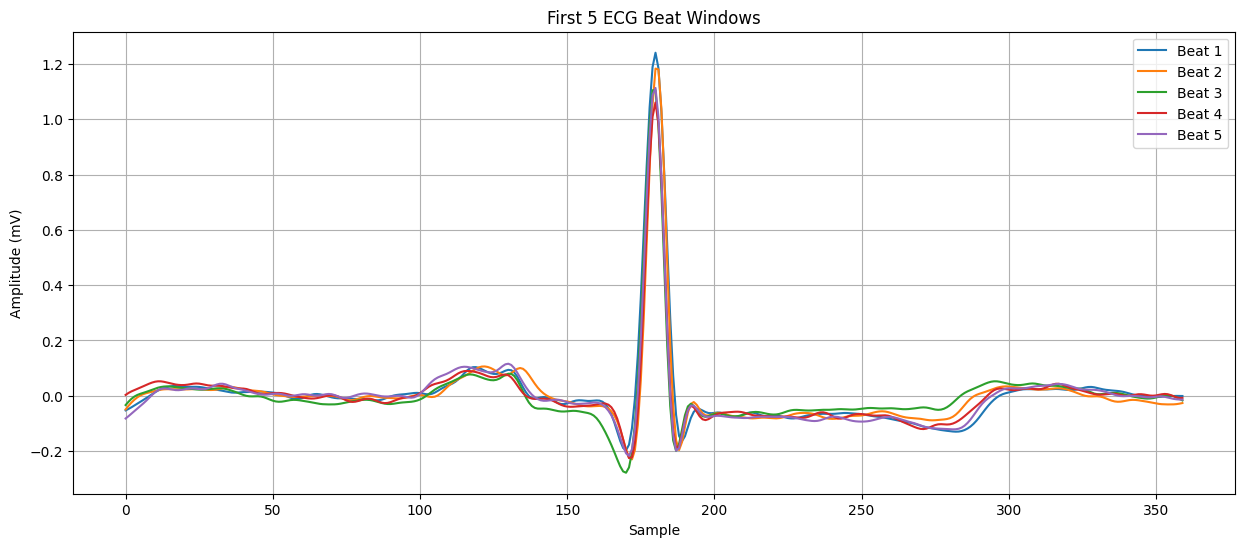

In [ ]:
# Block 21 — Visualize First 5 ECG Windows

plt.figure(figsize=(15, 6))

for i in range(min(5, len(ecg_windows))):
    plt.plot(ecg_windows[i], label=f"Beat {i+1}")

plt.title("First 5 ECG Beat Windows")
plt.xlabel("Sample")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Block 22 — ECG Feature Extraction

from scipy.stats import skew, kurtosis

features = []

for window in ecg_windows:
    mean_value = np.mean(window)
    std_value = np.std(window)
    min_value = np.min(window)
    max_value = np.max(window)
    median_value = np.median(window)
    rms_value = np.sqrt(np.mean(window ** 2))
    ptp_value = np.ptp(window)
    skew_value = skew(window)
    kurtosis_value = kurtosis(window)

    features.append([
        mean_value,
        std_value,
        min_value,
        max_value,
        median_value,
        rms_value,
        ptp_value,
        skew_value,
        kurtosis_value
    ])

feature_columns = [
    "Mean",
    "Standard_Deviation",
    "Minimum",
    "Maximum",
    "Median",
    "RMS",
    "Peak_to_Peak",
    "Skewness",
    "Kurtosis"
]

signal_features_df = pd.DataFrame(
    features,
    columns=feature_columns
)

print("ECG features extracted successfully!")
print("Feature Dataset Shape:", signal_features_df.shape)

signal_features_df.head()

ECG features extracted successfully!
Feature Dataset Shape: (2271, 9)


,Mean,Standard_Deviation,Minimum,Maximum,Median,RMS,Peak_to_Peak,Skewness,Kurtosis
0,0.006233,0.165881,-0.197444,1.240993,-0.004718,0.165998,1.438437,5.300879,32.033008
1,0.003665,0.149637,-0.230532,1.183630,-0.006076,0.149682,1.414162,5.600586,36.866744
2,0.001522,0.142326,-0.278717,1.105174,-0.016261,0.142335,1.383891,5.304128,34.825427
3,0.000997,0.134722,-0.225754,1.061056,-0.004427,0.134726,1.286810,5.211206,33.899633
4,0.000676,0.144432,-0.217574,1.113509,-0.002040,0.144433,1.331083,5.080471,32.282369


In [ ]:
# Block 23 — Feature Statistics

print("Statistical Summary of ECG Features:")

display(signal_features_df.describe())

Statistical Summary of ECG Features:


,Mean,Standard_Deviation,Minimum,Maximum,Median,RMS,Peak_to_Peak,Skewness,Kurtosis
count,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000
mean,0.000778,0.162368,-0.243401,1.229742,-0.012283,0.162499,1.473143,5.159061,32.252077
std,0.006600,0.021146,0.051094,0.123192,0.010302,0.021182,0.131543,0.340261,2.796187
min,-0.079697,0.114657,-2.459084,0.869077,-0.111418,0.114686,1.040698,-1.430958,5.337059
25%,-0.002860,0.147992,-0.253704,1.134187,-0.017542,0.148056,1.377135,4.984667,30.511832
50%,0.001119,0.159804,-0.241523,1.221255,-0.011546,0.159926,1.460755,5.198505,32.495219
75%,0.004854,0.172435,-0.229080,1.312517,-0.005691,0.172447,1.554841,5.371799,34.200211
max,0.069526,0.601570,-0.159700,1.692642,0.049508,0.601822,3.631143,6.158811,40.632409


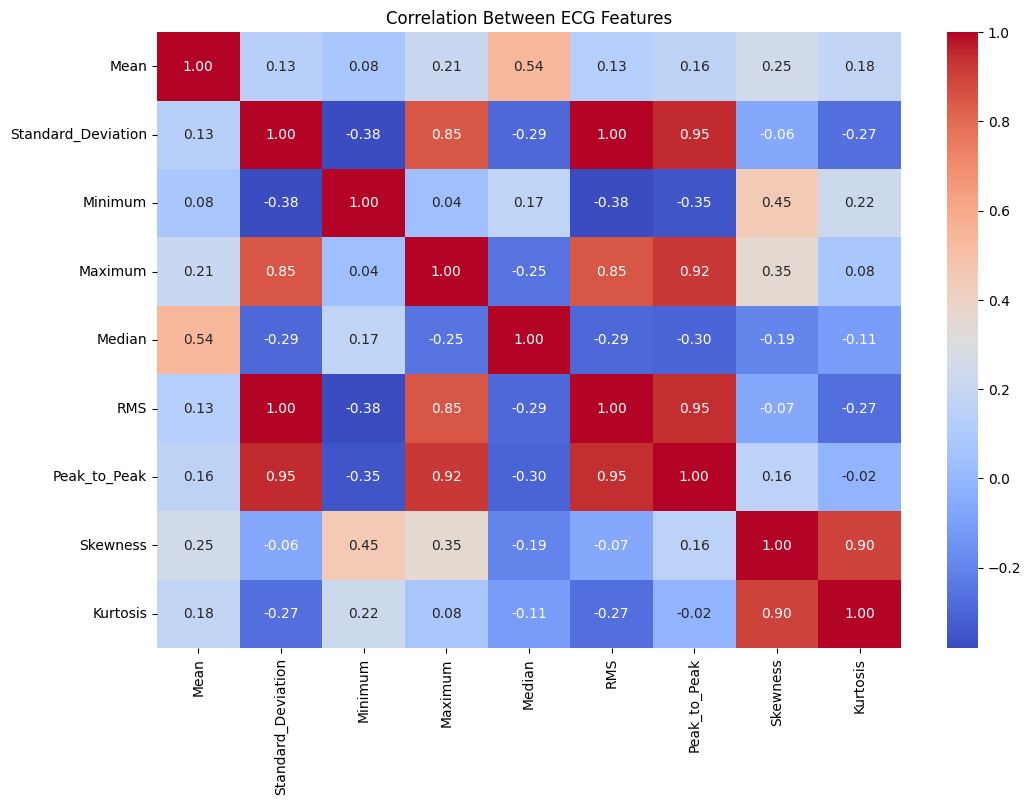

In [ ]:
# Block 24 — ECG Feature Correlation

plt.figure(figsize=(12, 8))

sns.heatmap(
    signal_features_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between ECG Features")
plt.show()

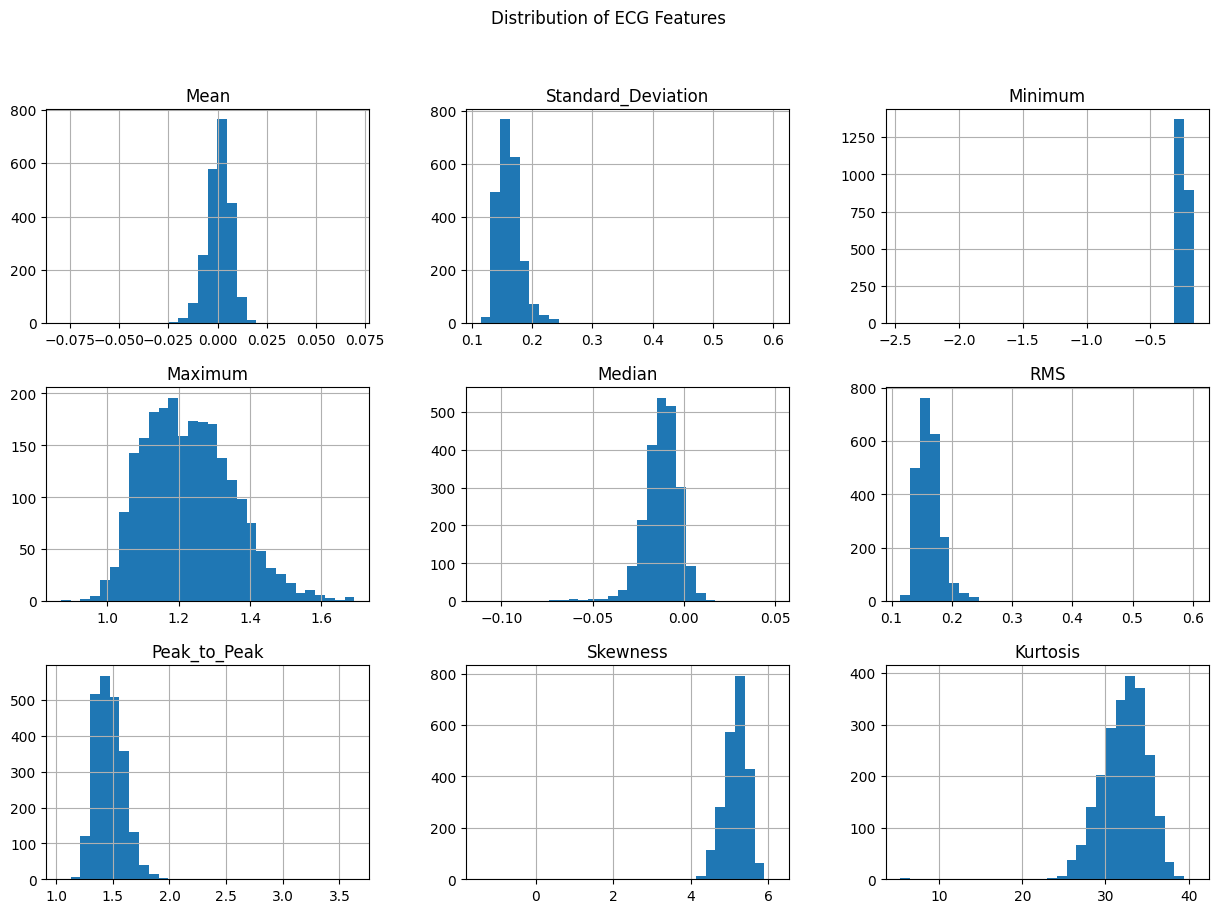

In [ ]:
# Block 25 — ECG Feature Distributions

signal_features_df.hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle("Distribution of ECG Features")
plt.show()

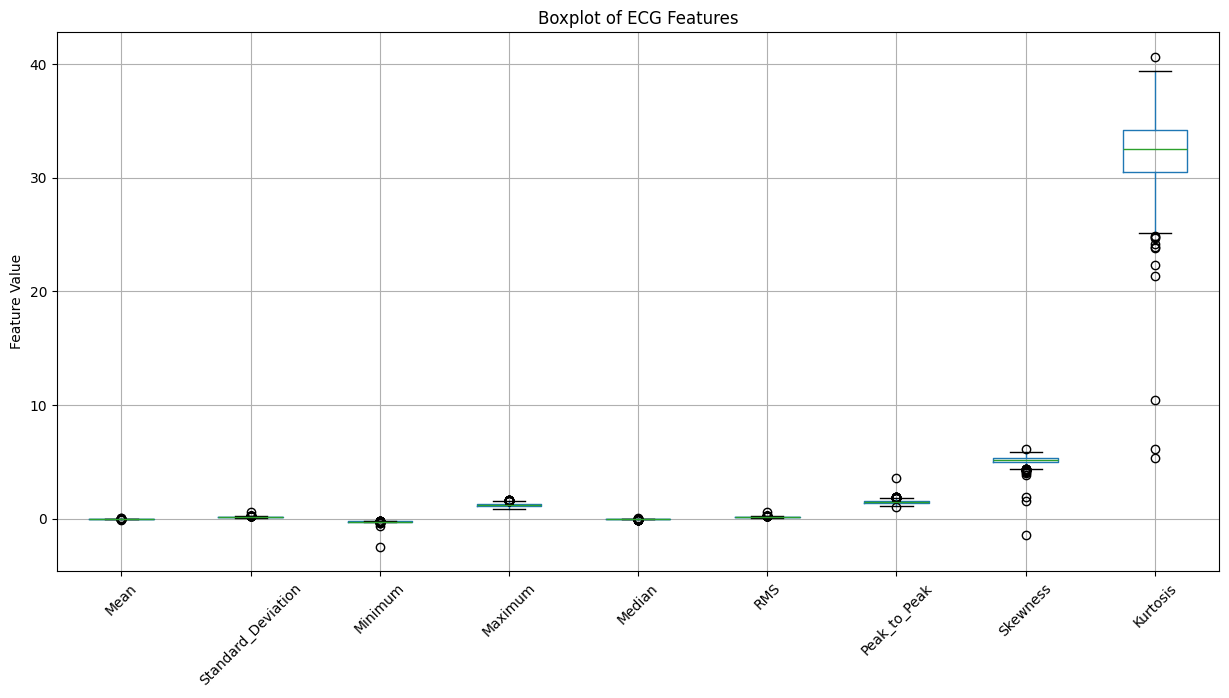

In [ ]:
# Block 26 — ECG Feature Boxplots

plt.figure(figsize=(15, 7))

signal_features_df.boxplot(
    rot=45
)

plt.title("Boxplot of ECG Features")
plt.ylabel("Feature Value")
plt.grid(True)

plt.show()

In [ ]:
# Block 27 — Normalize ECG Windows

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

ecg_windows_normalized = scaler.fit_transform(
    ecg_windows
)

print("ECG windows normalized successfully!")
print("Normalized Shape:", ecg_windows_normalized.shape)

ECG windows normalized successfully!
Normalized Shape: (2271, 360)


In [ ]:
# Block 28 — Verify Normalization

print("Mean of normalized data:",
      np.mean(ecg_windows_normalized))

print("Standard deviation of normalized data:",
      np.std(ecg_windows_normalized))

Mean of normalized data: -1.0762954694032341e-16
Standard deviation of normalized data: 0.9999999999999999


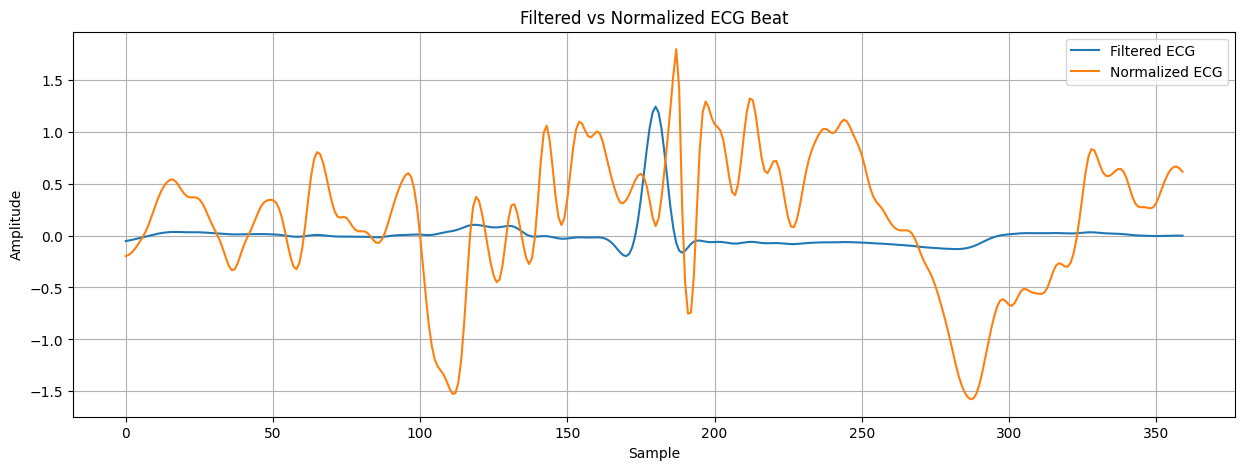

In [ ]:
# Block 29 — Raw vs Normalized ECG Beat

beat_number = 0

plt.figure(figsize=(15, 5))

plt.plot(
    ecg_windows[beat_number],
    label="Filtered ECG"
)

plt.plot(
    ecg_windows_normalized[beat_number],
    label="Normalized ECG"
)

plt.title("Filtered vs Normalized ECG Beat")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Block 30 — Model-Ready ECG Feature Dataset

model_ready_ecg = signal_features_df.copy()

print("Model-ready ECG feature dataset created!")

print("Shape:", model_ready_ecg.shape)

display(model_ready_ecg.head())

Model-ready ECG feature dataset created!
Shape: (2271, 9)


,Mean,Standard_Deviation,Minimum,Maximum,Median,RMS,Peak_to_Peak,Skewness,Kurtosis
0,0.006233,0.165881,-0.197444,1.240993,-0.004718,0.165998,1.438437,5.300879,32.033008
1,0.003665,0.149637,-0.230532,1.183630,-0.006076,0.149682,1.414162,5.600586,36.866744
2,0.001522,0.142326,-0.278717,1.105174,-0.016261,0.142335,1.383891,5.304128,34.825427
3,0.000997,0.134722,-0.225754,1.061056,-0.004427,0.134726,1.286810,5.211206,33.899633
4,0.000676,0.144432,-0.217574,1.113509,-0.002040,0.144433,1.331083,5.080471,32.282369


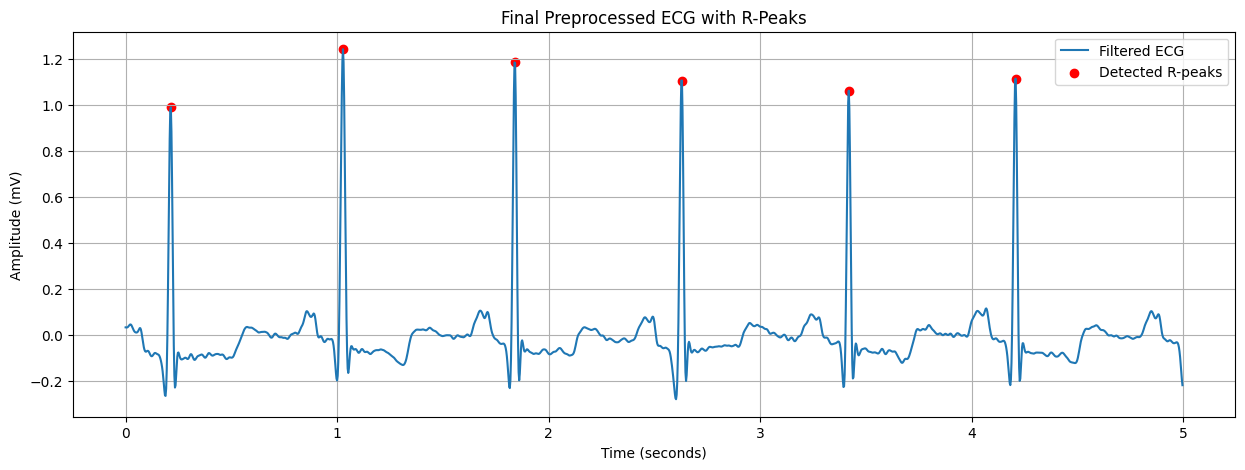

In [ ]:
# Block 35 — Final ECG Preprocessing Visualization

seconds = 5
samples = int(seconds * record.fs)

time = np.arange(samples) / record.fs

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    filtered_ecg[:samples],
    label="Filtered ECG"
)

peak_mask = peaks < samples

plt.scatter(
    time[peaks[peak_mask]],
    filtered_ecg[peaks[peak_mask]],
    color="red",
    label="Detected R-peaks"
)

plt.title("Final Preprocessed ECG with R-Peaks")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(True)

plt.show()